# Fire Spreading Advanced

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)
from src.data_preprocessing import sentinel_client
from src.fire_spreading_model import FireSpreadingAdvanced


## Sentinel Data:

In [30]:
# Setup Authentication
client_id = 'sh-83b3baad-681c-49ff-967c-a1fe3eed19a4'
client_secret = 'L9cE8ASdvwyY64jWo8nUJQRIZ37A0XpS'
sc = sentinel_client(client_id=client_id, client_secret=client_secret)

# Austria Fire Analysis and Simulation

This notebook handles data retrieval, target mask creation, and fire simulation for the Hirschwang fire in Austria using Sentinel-2 satellite imagery.  
Because a reference severity mask is available, the generated results can be compared against ground truth to verify that the implementation behaves as expected.

## Visualizing Before and After (True Color)

We define the bounding box of the Hirschwang fire area and retrieve Sentinel-2 imagery to visualize the impact of the fire before and after the event.

## Parameters

The following parameters must be specified manually:

### Spatial Parameters

- `lon_min, lat_min, lon_max, lat_max`  
  Bounding box coordinates defining the area of interest.

- `pixel_x, pixel_y`  
  Resolution of the output pixel grid.  
  Note: forcing a rectangular region into a square grid can introduce non-uniform spatial scaling and uneven effective resolution.

### Temporal Parameters

- `fire_start_date_1, fire_start_date_2`  
  Time range used to retrieve imagery from the beginning of the fire event.

- `observation_end_date_1, observation_end_date_2`  
  Time range used to retrieve imagery representing the end state of the fire.

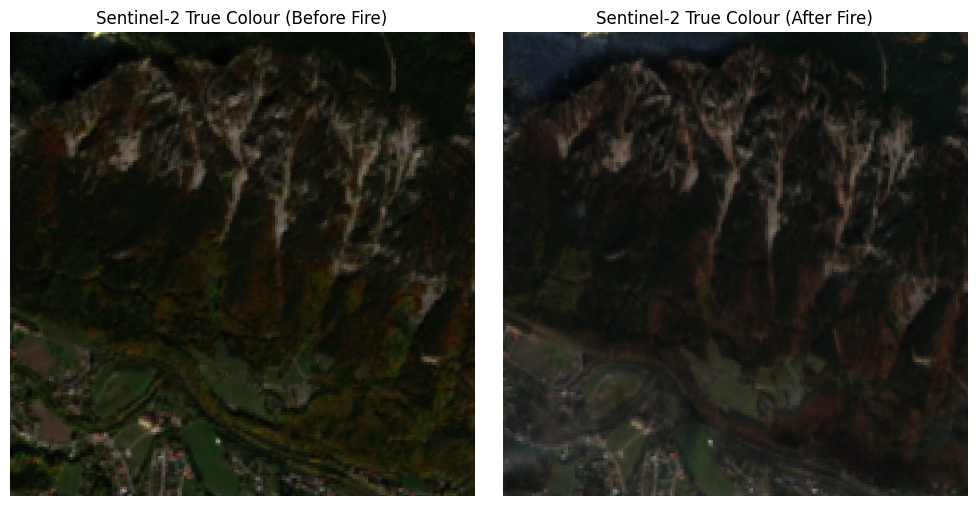

In [31]:
# Bounding box for the Fire start area
lon_min, lat_min, lon_max, lat_max = 15.812, 47.702, 15.838, 47.718
fire_start_date_1, fire_start_date_2 = "2021-10-20", "2021-10-25"
pixel_x, pixel_y = 500, 500 # pixel need to be adjusted for better resolution, but it will increase the runtime significantly
observation_end_date_1, observation_end_date_2 = "2021-11-10", "2021-11-11"

photo_true_colour_before = sc.get_photo(lon_min, lat_min, lon_max, lat_max, fire_start_date_1, fire_start_date_2, pixel_x, pixel_y, mode="true_colour")

photo_true_colour_after = sc.get_photo(lon_min, lat_min, lon_max, lat_max, observation_end_date_1, observation_end_date_2, pixel_x, pixel_y, mode="true_colour")

# Create side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Before fire
axes[0].imshow(photo_true_colour_before)
axes[0].set_title("Sentinel-2 True Colour (Before Fire)")
axes[0].axis("off")

# After fire
axes[1].imshow(photo_true_colour_after)
axes[1].set_title("Sentinel-2 True Colour (After Fire)")
axes[1].axis("off")

plt.tight_layout()
plt.show()



The true colour pictures appear to be the same. Further information is needed.

## Data Retrieval and Target Mask Generation
We extract the Burn Ratio (from the enviromental index NBR) to create a ground-truth mask. The simulation time T is calculated by multipling the number of days in real time by 24. Therefore one simulation timestep would corespond to one hour.

The same procedure is done here: https://www.geochange-consulting.com/wp-content/uploads/2025/08/Melzner_etal_2025.pdf.
Since we get the same ncolour severity mask it can be asumed that the data retrival worked.

Simulation time (T): 504 time steps


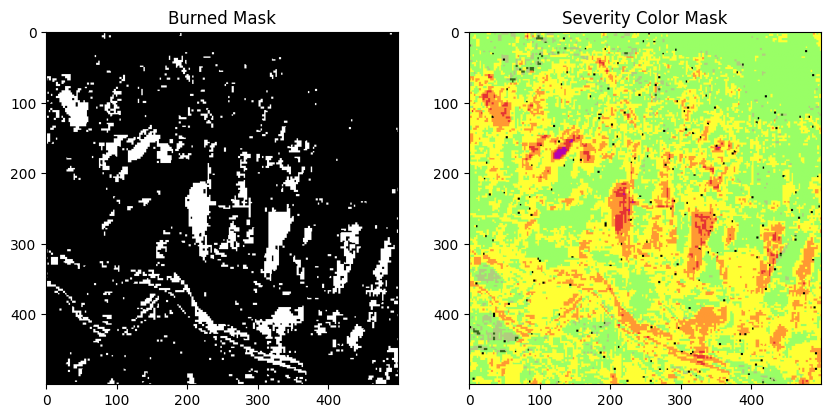

In [32]:
# Retrieve data
fuel_before, water_before, moisture_before, burnt_before = sc.get_data(lon_min, lat_min, lon_max, lat_max, fire_start_date_1, fire_start_date_2, pixel_x, pixel_y)
topo = sc.get_topo(lon_min, lat_min, lon_max, lat_max, pixel_x, pixel_y)
fuel_after_real_data, water_after_real_data, moisture_after_real_data, burnt_after_real_data = sc.get_data(lon_min, lat_min, lon_max, lat_max, observation_end_date_1, observation_end_date_2, pixel_x, pixel_y)

#dNBR = (NBR_before - NBR_after)
dnbr = (burnt_before - burnt_after_real_data)

# Create the Target Burn Mask based on NBR and water levels
# white pixels indicate areas that were burned, while black pixels indicate unburned areas
target_mask = (dnbr > 0.1)

# Calculate simulation time in hours
T = sc.get_simulation_time(fire_start_date_1, observation_end_date_1) * 24
print(f"Simulation time (T): {T} time steps")

# severity mask based on dNBR
severity_color_mask, burned_mask = sc.get_severity_mask(dnbr)

# visualize the burned_mask and severity_color_mask
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(burned_mask, cmap='gray')
plt.title("Burned Mask")
plt.subplot(1,2,2)
plt.imshow(severity_color_mask)
plt.title("Severity Color Mask")
plt.show()


## Simulation Overview

This simulation initializes a fire spread model on a 2D grid of size `pixel_x × pixel_y`.

## Core Structure

- `max_H`, `max_F`, `max_O`  
  Define normalized upper bounds for heat, fuel, and oxygen.

- `start_cells`  
  Initial ignition points where the fire starts.

- Environmental inputs:
  - `fuel_mask`
  - `water_mask`
  - `moisture_mask`
  - `topo_mask`  

  These define spatial variation in fuel availability, water presence, moisture, and terrain.

## Key Physical Processes

- `mu_H` and `mu_O`  
  Control diffusion of heat and oxygen to neighboring cells. These define baseline spread behavior or 'speed' of the spread.

- `dF`, `dO`, `dW`  
  Consumption and decay rates for fuel, oxygen, and moisture during burning.

- `wind_strength_factor`  
  Controls how strongly wind biases directional spread by modifying the effective diffusion direction.

- `k_slope`  
  Introduces terrain influence by converting elevation gradients into directional bias, effectively steering spread along slopes.


## Ignition and Extinction Rules

A cell ignites when:
- heat exceeds `ignition_temp`
- fuel exceeds `ignition_fuel`
- oxygen exceeds `ignition_oxy`
- moisture has evaporated

A burning cell extinguishes when:
- fuel drops below `extinction_fuel_ratio`, or
- oxygen drops below `extinction_oxy`

In [33]:
# Should be put in source but is here for now

def geo_to_pixel(lat, lon, lat_min, lat_max, lon_min, lon_max, pixel_x, pixel_y):
    # X-Pixel (Longitude / Column)
    x = int(((lon - lon_min) / (lon_max - lon_min)) * (pixel_x - 1))
        
    # Y-Pixel (Latitude / Row - inverted)
    y = int((1 - (lat - lat_min) / (lat_max - lat_min)) * (pixel_y - 1))
        
    # Restrict values to stay inside the image array boundaries
    x = max(0, min(pixel_x - 1, x))
    y = max(0, min(pixel_y - 1, y))
        
    return x, y
    
# Geographical origin point in the bounding box: Mittagsstein https://noe.orf.at/magazin/stories/3186505/
start_lat=47.718
start_lon=15.824
starting_cell = (sc.geo_to_pixel(start_lat, start_lon, lat_min, lat_max, lon_min, lon_max, pixel_x, pixel_y))

# Tuning
- `mu_H`: speed
- `dF`: how long a cell burns
- `k_slope`: how much the slope contibutes
- `wind_strength_factor`: how much the wind contributes
- `extinction_fuel_ratio`: when it stops burning (note: this is a ratio of fuel now compared to the start(grasland vs forrest)
- `dW`: different speeds for grasland and forest

### Could be tuned
- `mu_O`
- `dO`
- `ignition_temp` 

### Environmental inputs (not tuned)
- `fuel_mask`, `water_mask`, `moisture_mask`, `topo_mask`
- `start_cells`
- `wind`

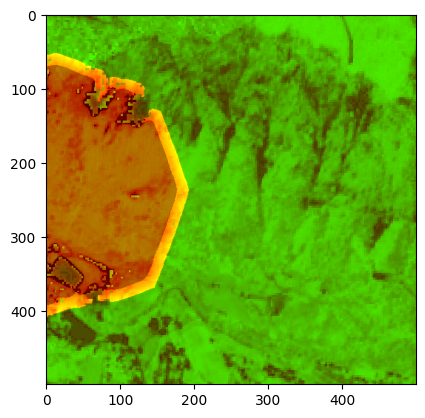

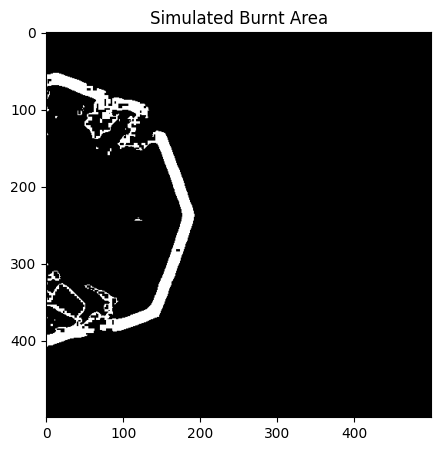

In [35]:
# Initialize simulation with hourly-calibrated parameters
sim = FireSpreadingAdvanced(
    n=pixel_x, 
    m=pixel_y, 
    max_H=1.0, max_F=1.0, max_O=1.0,
    mu_H=0.1, # Heat diffusion coefficients TUNE
    mu_O=0.1, # Oxygen diffusion coefficients (is probably not important but could be tuned)
    dF=0.01, # Fuel consumption rate TUNE
    dO=0.02, # Oxygen consumption rate (is probably not important but could be tuned)
    dW=0.05,  # Evaporation rate TUNE
    ignition_temp=0.4, #is probably not important but could be tuned
    ignition_fuel=0.3,
    ignition_oxy=0.76,
    extinction_oxy=0.19, 
    extinction_fuel_ratio=0.1, # TUNE
    wind = [0,0],
    start_cells=[starting_cell],
    fuel_mask=fuel_before, 
    water_mask=water_before, 
    moisture_mask=moisture_before,
    topo_mask=topo,
    k_slope=0.1, # TUNE
    wind_strength_factor=0.5 # TUNE
)

# Run simulation and save output
sim.run_simulation(T=T, gif_name="fire_simulation")

# calculate the burnt area from the simulation results
simulated_burnt_area = sim.calculate_simulation_burned_mask()

# Visualize the simulated binary burnt area 
plt.figure(figsize=(5,5))
plt.imshow(simulated_burnt_area, cmap='grey')
plt.title("Simulated Burnt Area")
plt.show()